In [1]:
import os
import json
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
try:
    import soundata
    HAS_SOUNDATA = True
except ImportError:
    HAS_SOUNDATA = False
    print("soundata not installed -- pip install soundata")
    print("Falling back to synthetic noise only.")


In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
JSON_DIR   = 'Data/Labeled/All-JSON'
AUDIO_DIRS = ['Data/Range', 'Data/Substation']   # actual PCM clips
WINDOW     = 2048                                 # ~21 ms at 96 kHz
CLASSES    = ['muzzle_blast', 'shockwave', 'none']   # label 0 / 1 / 2
EVENT_IDX  = {'muzzle_blast': 0, 'shockwave': 1}     # for JSON parsing

# ── Build filename → path lookup (one os.walk per audio root) ─────────────────
print('Scanning audio files ...')
file_lookup = {}
for audio_dir in AUDIO_DIRS:
    for root, _, files in os.walk(audio_dir):
        for f in files:
            file_lookup[f] = os.path.join(root, f)
print(f'  {len(file_lookup):,} audio files indexed')

# ── Parse every JSON and collect one row per event ────────────────────────────
rows = []
for fname in os.listdir(JSON_DIR):
    if not fname.endswith('.json') or fname == 'demo_labels_out.json':
        continue
    with open(os.path.join(JSON_DIR, fname)) as f:
        d = json.load(f)
    pcm_sr = d['pcm_sr']
    for clip, entries in d['labels'].items():
        path = file_lookup.get(clip)
        if path is None:
            continue                      # audio file not on this machine
        for e in entries:
            if e['class'] not in EVENT_IDX:
                continue
            center = int((e['t1'] + e['t2']) / 2 * pcm_sr)
            rows.append({
                'path':   path,
                'label':  EVENT_IDX[e['class']],
                'event':  e['class'],
                'center': center,
            })

df = pd.DataFrame(rows)
print('\nEvents per class:')
print(df['event'].value_counts())
print(f'\nTotal events: {len(df)}')

Scanning audio files ...
  31,971 audio files indexed

Events per class:
event
muzzle_blast    4238
shockwave        467
Name: count, dtype: int64

Total events: 4705


In [3]:
# ── Noise corpus ──────────────────────────────────────────────────────────────
# Composite noise is generated by ALWAYS combining two source types:
#   1. Colored noise floor  (pink 1/f or brown 1/f²) — wind, general ambiance
#   2. 1–3 UrbanSound8K clips at random volumes  — traffic, crowds, sirens, …
#
# Every call to sample_composite_noise() draws from both sources and sums them.
# Each UrbanSound8K clip is individually normalised before mixing so that the
# random per-clip volume weight controls relative loudness, not recording level.
# The final sum is normalised to unit std before being passed to mix_at_snr or
# the NoneDataset amplitude scaler.

SAMPLE_RATE = 96000
P_AUG       = 0.5       # fraction of training event samples that receive noise
SNR_RANGE   = (-5, 20)  # dB: −5 = very noisy, +20 = barely audible noise


# ── UrbanSound8K loader ──────────────────────────────────────────────────────
def load_urbansound8k_clips(max_clips=1000):
    """Download (first run only) and load UrbanSound8K clips at original SR."""
    if not HAS_SOUNDATA:
        return []
    try:
        ds = soundata.initialize('urbansound8k')
        ds.download()
    except Exception as e:
        print(f'UrbanSound8K download failed: {e}')
        return []
    clips, skipped = [], 0
    for clip_id in ds.clip_ids[:max_clips]:
        try:
            result = ds.clip(clip_id).audio
            if result is None:
                skipped += 1
                continue
            audio, sr = result
            if audio is None or audio.size == 0:
                skipped += 1
                continue
            if audio.ndim == 2:
                audio = audio.mean(axis=0)
            clips.append((audio.astype(np.float32), int(sr)))
        except Exception:
            skipped += 1
    print(f'UrbanSound8K: {len(clips)} clips loaded  ({skipped} skipped)')
    return clips


# ── Noise helpers ─────────────────────────────────────────────────────────────
def colored_noise(n, exponent=1.0):
    """FFT-shaped noise normalised to unit std.  exponent=1 pink,  2 brown."""
    white  = np.random.randn(n)
    freqs  = np.fft.rfftfreq(n)
    freqs[0] = 1e-10
    shaped = np.fft.irfft(np.fft.rfft(white) * freqs ** (-exponent / 2.0), n)
    shaped = shaped.astype(np.float32)
    std    = shaped.std()
    return shaped / std if std > 1e-10 else shaped


def sample_composite_noise(n, noise_clips):
    """
    Composite ambient noise — always combines:
      * one colored noise floor (pink or brown, random weight 0.3–1.0)
      * 1–3 UrbanSound8K clips (each normalised, random weight 0.2–1.0)
    Result is normalised to unit std so mix_at_snr can apply any target SNR.
    Falls back to colored-noise-only when noise_clips is empty.
    """
    # Colored noise floor (always present)
    floor = colored_noise(n, exponent=float(np.random.choice([1.0, 2.0])))
    composite = floor * np.random.uniform(0.3, 1.0)

    # 1–3 UrbanSound8K clips layered at independent random volumes
    if noise_clips:
        for _ in range(np.random.randint(1, 4)):
            audio, sr = noise_clips[np.random.randint(len(noise_clips))]
            n_src = max(2, int(n * sr / SAMPLE_RATE))
            if len(audio) > n_src:
                s   = np.random.randint(0, len(audio) - n_src)
                seg = audio[s:s + n_src]
            else:
                reps = n_src // len(audio) + 1
                seg  = np.tile(audio, reps)[:n_src]
            # Resample to n via linear interpolation
            clip = np.interp(
                np.linspace(0, len(seg) - 1, n),
                np.arange(len(seg)), seg,
            ).astype(np.float32)
            # Normalise each clip independently before mixing
            clip_std = clip.std()
            if clip_std > 1e-10:
                clip /= clip_std
            composite += clip * np.random.uniform(0.2, 1.0)

    # Normalise the mixture to unit std
    std = float(composite.std())
    return (composite / std).astype(np.float32) if std > 1e-10 else composite.astype(np.float32)


def mix_at_snr(signal, noise, snr_db):
    """Scale noise so that signal+noise achieves the requested SNR (dB)."""
    sig_pwr = float(np.mean(signal ** 2))
    noi_pwr = float(np.mean(noise  ** 2))
    if noi_pwr < 1e-12 or sig_pwr < 1e-12:
        return signal
    scale = np.sqrt(sig_pwr / (noi_pwr * 10.0 ** (snr_db / 10.0)))
    return np.clip(signal + scale * noise, -1.0, 1.0).astype(np.float32)


print('Loading UrbanSound8K ...')
urbansound_clips = load_urbansound8k_clips()
if urbansound_clips:
    print(f'Noise corpus ready: {len(urbansound_clips)} real-world clips + colored noise floor')
else:
    print('Noise corpus ready: colored noise floor only  (UrbanSound8K unavailable)')


Loading UrbanSound8K ...


INFO: Downloading ['all', 'index']. Index is being stored in C:\Users\choub\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soundata\datasets\indexes, and the rest of files in /tmp\sound_datasets\urbansound8k
INFO: [all] downloading UrbanSound8K.tar.gz
INFO: /tmp\sound_datasets\urbansound8k\UrbanSound8K.tar.gz already exists and will not be downloaded. Rerun with force_overwrite=True to delete this file and force the download.
INFO: /tmp\sound_datasets\urbansound8k\audio already exists. Run with force_overwrite=True to download from scratch
INFO: /tmp\sound_datasets\urbansound8k\FREESOUNDCREDITS.txt already exists. Run with force_overwrite=True to download from scratch
INFO: /tmp\sound_datasets\urbansound8k\metadata already exists. Run with force_overwrite=True to download from scratch
INFO: /tmp\sound_datasets\urbansound8k\UrbanSound8K_README.txt already exists. Run with force_overwrite=True to download from s

UrbanSound8K: 1000 clips loaded  (0 skipped)
Noise corpus ready: 1000 real-world clips + colored noise floor


In [4]:
# ── Dataset ───────────────────────────────────────────────────────────────────
class EventDataset(Dataset):
    def __init__(self, df, window=WINDOW, augment=False,
                 noise_clips=None, p_aug=P_AUG, snr_range=SNR_RANGE,
                 return_snr=False):
        self.df          = df.reset_index(drop=True)
        self.half        = window // 2
        self.augment     = augment
        self.noise_clips = noise_clips or []
        self.p_aug       = p_aug
        self.snr_range   = snr_range
        # return_snr=True makes __getitem__ yield (audio, label, snr_db) so the
        # corrupted test set can later be sliced by SNR band.  snr_db is NaN
        # when no noise was mixed into the sample.
        self.return_snr  = return_snr

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        audio = np.fromfile(row['path'], dtype=np.int16).astype(np.float32) / 32768.0
        n     = len(audio)

        start = int(row['center']) - self.half
        start = max(0, min(start, n - 2 * self.half))
        chunk = audio[start : start + 2 * self.half]

        if len(chunk) < 2 * self.half:
            chunk = np.pad(chunk, (0, 2 * self.half - len(chunk)))

        snr_db = float('nan')
        if self.augment and np.random.random() < self.p_aug:
            snr_db = float(np.random.uniform(*self.snr_range))
            chunk  = mix_at_snr(
                chunk,
                sample_composite_noise(len(chunk), self.noise_clips),
                snr_db,
            )

        x = torch.from_numpy(chunk).unsqueeze(0)
        if self.return_snr:
            return x, int(row['label']), snr_db
        return x, int(row['label'])


In [5]:
# ── Model: 1-D CNN binary classifier ─────────────────────────────────────────
class EventCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # 2048 → 512
            nn.Conv1d(1,  32, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(32),  nn.ReLU(inplace=True), nn.MaxPool1d(2),
            # 512 → 128
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm1d(64),  nn.ReLU(inplace=True), nn.MaxPool1d(2),
            # 128 → 1
            nn.Conv1d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))

In [6]:
# ── Attention model: same CNN backbone + Multi-Head Self-Attention ────────────
class AttentionEventCNN(nn.Module):
    """
    Replaces AdaptiveAvgPool with Multi-Head Self-Attention over time steps,
    letting the model learn WHICH part of the window is discriminative.
    """
    def __init__(self, num_classes=2, num_heads=4):
        super().__init__()
        self.features = nn.Sequential(
            # 2048 → 512
            nn.Conv1d(1,  32, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(32),  nn.ReLU(inplace=True), nn.MaxPool1d(2),
            # 512 → 128
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm1d(64),  nn.ReLU(inplace=True), nn.MaxPool1d(2),
            # 128 → 32
            nn.Conv1d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.MaxPool1d(2),
            # keeps sequence (no global pool)
        )
        # Multi-head self-attention over the time dimension
        self.attn  = nn.MultiheadAttention(embed_dim=128, num_heads=num_heads,
                                            dropout=0.1, batch_first=True)
        self.norm  = nn.LayerNorm(128)
        self.head  = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        feat = self.features(x)              # [B, 128, T]
        feat = feat.permute(0, 2, 1)         # [B, T, 128]  (batch_first)
        attn_out, _ = self.attn(feat, feat, feat)
        feat = self.norm(feat + attn_out)    # residual connection
        feat = feat.mean(dim=1)              # global average over time → [B, 128]
        return self.head(feat)

In [7]:
# -- GNN model: temporal graph over audio frames ---------------------------------
from torch_geometric.nn import GCNConv, global_mean_pool

class AudioGNN(nn.Module):
    def __init__(self, num_classes=2, num_nodes=32, node_dim=64, k=2):
        super().__init__()
        self.num_nodes = num_nodes
        frame_len      = WINDOW // num_nodes   # 2048 / 32 = 64 samples per frame

        # Small 1-D CNN encodes each 64-sample frame into a node feature vector
        self.frame_enc = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(32), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(32, node_dim),
        )
        self.conv1 = GCNConv(node_dim, 128)
        self.conv2 = GCNConv(128,      128)
        self.bn1   = nn.BatchNorm1d(128)
        self.bn2   = nn.BatchNorm1d(128)
        self.head  = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(64, num_classes),
        )
        self.register_buffer('edge_index_single', self._build_edges(num_nodes, k))

    @staticmethod
    def _build_edges(n, k):
        rows, cols = [], []
        for i in range(n):
            for j in range(max(0, i - k), min(n, i + k + 1)):
                rows.append(i); cols.append(j)
        return torch.tensor([rows, cols], dtype=torch.long)

    def forward(self, x):
        B, _, L  = x.shape
        N, fl    = self.num_nodes, L // self.num_nodes
        frames   = x.view(B * N, 1, fl)
        feats    = self.frame_enc(frames)
        E        = self.edge_index_single.size(1)
        offsets  = torch.arange(B, device=x.device).repeat_interleave(E) * N
        edge_idx = self.edge_index_single.repeat(1, B) + offsets.unsqueeze(0)
        batch    = torch.arange(B, device=x.device).repeat_interleave(N)
        h = F.relu(self.bn1(self.conv1(feats,  edge_idx)))
        h = F.relu(self.bn2(self.conv2(h,      edge_idx)))
        h = global_mean_pool(h, batch)
        return self.head(h)


In [8]:
# -- CNN + Transformer -----------------------------------------------------------
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class CNNTransformer(nn.Module):
    """
    CNN extracts local features -> Transformer encoder captures long-range
    temporal dependencies with positional encoding -> CLS token classifies.
    """
    def __init__(self, num_classes=2, d_model=128, nhead=4, num_layers=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1,  32, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(32),    nn.ReLU(inplace=True), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm1d(64),    nn.ReLU(inplace=True), nn.MaxPool1d(2),
            nn.Conv1d(64, d_model, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(d_model), nn.ReLU(inplace=True),
            # output shape: [B, d_model, T=32]
        )
        self.pos_enc    = PositionalEncoding(d_model)
        self.cls_token  = nn.Parameter(torch.zeros(1, 1, d_model))
        enc_layer       = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256,
            dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        feat = self.features(x).permute(0, 2, 1)        # [B, T, d_model]
        feat = self.pos_enc(feat)
        cls  = self.cls_token.expand(x.size(0), -1, -1) # [B, 1, d_model]
        feat = torch.cat([cls, feat], dim=1)             # [B, T+1, d_model]
        out  = self.transformer(feat)
        return self.head(out[:, 0])                      # CLS token -> head


In [9]:
# -- CNN + Attention (additive / soft-attention pooling) -------------------------

class CNNWithAttention(nn.Module):
    """
    CNN backbone + a learnable soft-attention pooling layer.
    Instead of averaging all time steps equally (AdaptiveAvgPool),
    the model learns a scalar importance score per time step and
    computes a weighted sum -- focusing on the most discriminative frames.
    """
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1,  32, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(32),  nn.ReLU(inplace=True), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm1d(64),  nn.ReLU(inplace=True), nn.MaxPool1d(2),
            nn.Conv1d(64, 128,   kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            # keeps sequence -- no global pool
        )
        # Attention scorer: maps each time-step feature to a scalar weight
        self.attn_scorer = nn.Sequential(
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, 1),
        )
        self.head = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        feat    = self.features(x).permute(0, 2, 1)  # [B, T, 128]
        scores  = self.attn_scorer(feat)              # [B, T, 1]
        weights = torch.softmax(scores, dim=1)        # [B, T, 1]  (sum to 1 over T)
        context = (weights * feat).sum(dim=1)         # [B, 128]
        return self.head(context)


In [10]:
# -- Pure Transformer (Audio ViT style) ------------------------------------------
# Unlike CNNTransformer which uses a CNN backbone, this model processes raw audio
# directly: splits the window into fixed-size patches, linearly embeds each patch,
# adds learnable positional embeddings, then runs a full Transformer encoder.

class AudioTransformer(nn.Module):
    def __init__(self, num_classes=2, patch_size=64, d_model=128, nhead=4, num_layers=4):
        super().__init__()
        self.patch_size  = patch_size
        num_patches      = WINDOW // patch_size     # 2048 / 64 = 32 patches

        # Linear projection of each raw patch -> d_model
        self.patch_embed = nn.Linear(patch_size, d_model)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, d_model))
        # Learnable positional embeddings (one per patch + CLS)
        self.pos_embed   = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256,
            dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(64, num_classes),
        )

        nn.init.trunc_normal_(self.pos_embed,  std=0.02)
        nn.init.trunc_normal_(self.cls_token,  std=0.02)

    def forward(self, x):
        B  = x.size(0)
        x  = x.squeeze(1)                                    # [B, 2048]
        patches = x.view(B, -1, self.patch_size)             # [B, 32, 64]
        feat    = self.patch_embed(patches)                   # [B, 32, d_model]
        cls     = self.cls_token.expand(B, -1, -1)           # [B, 1,  d_model]
        feat    = torch.cat([cls, feat], dim=1) + self.pos_embed  # [B, 33, d_model]
        out     = self.norm(self.transformer(feat)[:, 0])    # CLS token
        return self.head(out)


In [11]:
# ── NoneDataset: generates the third 'none' class ────────────────────────────
# noisy=True  (training + noisy test) → composite noise at a random RMS level
# noisy=False (clean test)            → silence (all zeros)

class NoneDataset(Dataset):
    def __init__(self, n_samples, window=WINDOW, noisy=False,
                 noise_clips=None, snr_range=SNR_RANGE):
        self.n           = n_samples
        self.half        = window // 2
        self.noisy       = noisy
        self.noise_clips = noise_clips or []
        self.snr_range   = snr_range
        self.none_label  = CLASSES.index('none')   # = 2

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        n = 2 * self.half
        if self.noisy:
            chunk = sample_composite_noise(n, self.noise_clips)
            # Normalise to a realistic RMS in [0.05, 0.3] (unit-std noise is
            # too loud; this range matches typical outdoor ambient recordings).
            rms = float(np.sqrt(np.mean(chunk ** 2)))
            if rms > 1e-10:
                chunk = (chunk / rms * np.random.uniform(0.05, 0.3)).astype(np.float32)
        else:
            chunk = np.zeros(n, dtype=np.float32)
        return torch.from_numpy(chunk).unsqueeze(0), self.none_label


In [12]:
# ── Train / test split + 'none' class samples ────────────────────────────────
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

# Roughly match the minority (shockwave) count so 'none' doesn't overwhelm.
N_NONE_TRAIN = int((train_df['label'] == 1).sum())   # ≈ shockwave train count
N_NONE_TEST  = int((test_df['label']  == 1).sum())   # ≈ shockwave test count
print(f'Train: {len(train_df)} events + {N_NONE_TRAIN} none  '
      f'| Test: {len(test_df)} events + {N_NONE_TEST} none')
print('Train class dist:', train_df['event'].value_counts().to_dict())
print('Test  class dist:', test_df['event'].value_counts().to_dict())

# ── Clean test loader ─────────────────────────────────────────────────────────
test_loader = DataLoader(
    torch.utils.data.ConcatDataset([
        EventDataset(test_df, augment=False),
        NoneDataset(N_NONE_TEST, noisy=False),             # silence
    ]),
    batch_size=64, shuffle=False, num_workers=0)

# ── Training loader (CLEAN — NO noise augmentation) ──────────────────────────
# This notebook is the "trained without noise" baseline: events are used as
# clean waveform chunks (augment=False) and the 'none' class is silence
# (noisy=False), so the models NEVER see UrbanSound8K or synthetic noise during
# training.  The clean and noisy TEST loaders are left identical to the
# noise-augmented notebook so the two experiments can be compared head-to-head.
train_loader = DataLoader(
    torch.utils.data.ConcatDataset([
        EventDataset(train_df, augment=False),             # no noise mixed into events
        NoneDataset(N_NONE_TRAIN, noisy=False),            # 'none' = silence, not noise
    ]),
    batch_size=64, shuffle=True, num_workers=0)

# ── Noisy test loader (pre-generated, deterministic) ─────────────────────────
print(f'\nPre-generating noisy test set (seed=42, SNR {SNR_RANGE[0]}–{SNR_RANGE[1]} dB) ...')
np.random.seed(42)
# One pass captures audio, label AND the mixing SNR together, so the corrupted
# predictions can be sliced by SNR band later without regenerating any noise.
_ev_ds   = EventDataset(test_df, augment=True, p_aug=1.0,
                        noise_clips=urbansound_clips, return_snr=True)
_none_ds = NoneDataset(N_NONE_TEST, noisy=True, noise_clips=urbansound_clips)

_xs, _ys, _snrs = [], [], []
for i in tqdm(range(len(_ev_ds)), desc='  noisy events', leave=False):
    x, y, snr = _ev_ds[i]
    _xs.append(x); _ys.append(y); _snrs.append(snr)
for i in tqdm(range(len(_none_ds)), desc='  noisy none  ', leave=False):
    x, y = _none_ds[i]
    # A 'none' sample is pure ambience with no underlying signal, so it has no
    # SNR and belongs to no band.
    _xs.append(x); _ys.append(y); _snrs.append(float('nan'))
np.random.seed(None)

_noisy_xs = torch.stack(_xs)
_noisy_ys = torch.tensor(_ys, dtype=torch.long)
# Aligned with noisy_test_loader (shuffle=False), so evaluate_model's output
# can be indexed with this array directly.
noisy_snr = np.array(_snrs, dtype=np.float64)

noisy_test_loader = DataLoader(
    torch.utils.data.TensorDataset(_noisy_xs, _noisy_ys),
    batch_size=64, shuffle=False, num_workers=0)
print(f'Noisy test set: {len(_noisy_ys)} samples '
      f'({len(_ev_ds)} events + {len(_none_ds)} none)')

# -- SNR bands for the corrupted-set breakdown --------------------------------
# Three equal-width bands spanning SNR_RANGE, rounded to whole dB for reporting.
# A single aggregate noisy score averages over the entire sweep and hides the
# fact that accuracy is a strong function of SNR; the bands are what tells a
# deployment engineer where the system is trustworthy and where it is not.
_edges = np.round(np.linspace(SNR_RANGE[0], SNR_RANGE[1], 4)).astype(int)
SNR_BANDS = [
    ('Low',    int(_edges[0]), int(_edges[1])),   # worst case - loud ambience
    ('Medium', int(_edges[1]), int(_edges[2])),
    ('High',   int(_edges[2]), int(_edges[3])),   # best case - event dominates
]
SNR_BAND_LABEL = {n: f'{n} ({lo:+d} to {hi:+d} dB)' for n, lo, hi in SNR_BANDS}


def snr_band_mask(snr, lo, hi, include_hi=False):
    """Boolean mask for one SNR band.  NaN (the 'none' samples) compares False
    against every operand, so they never fall into a band."""
    return (snr >= lo) & ((snr <= hi) if include_hi else (snr < hi))


for _n, _lo, _hi in SNR_BANDS:
    _m = snr_band_mask(noisy_snr, _lo, _hi, include_hi=(_n == SNR_BANDS[-1][0]))
    print(f'  {SNR_BAND_LABEL[_n]:<24} {int(_m.sum()):4d} event samples')
print(f'  {"none (no SNR)":<24} {int(np.isnan(noisy_snr).sum()):4d} samples')

Train: 3764 events + 374 none  | Test: 941 events + 93 none
Train class dist: {'muzzle_blast': 3390, 'shockwave': 374}
Test  class dist: {'muzzle_blast': 848, 'shockwave': 93}

Pre-generating noisy test set (seed=42, SNR -5–20 dB) ...


Noisy test set: 1034 samples (941 events + 93 none)
  Low (-5 to +3 dB)         283 event samples
  Medium (+3 to +12 dB)     335 event samples
  High (+12 to +20 dB)      323 event samples
  none (no SNR)              93 samples


In [13]:
# ── Shared setup ─────────────────────────────────────────────────────────────
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_amp = device.type == 'cuda'
print(f'Device: {device}')

# Inverse-frequency weights for all 3 classes based on training split counts
n_counts = np.array([
    (train_df['label'] == 0).sum(),   # muzzle_blast
    (train_df['label'] == 1).sum(),   # shockwave
    N_NONE_TRAIN,                      # none
], dtype=np.float32)
weights = torch.tensor(1.0 / n_counts)
weights = (weights / weights.sum() * len(CLASSES)).to(device)
print(f'Class counts  : muzzle={n_counts[0]:.0f}  shockwave={n_counts[1]:.0f}  none={n_counts[2]:.0f}')
print(f'Class weights : {[f"{w:.3f}" for w in weights.cpu().numpy()]}')

EPOCHS = 20

def train_model(model, name, epochs=EPOCHS):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    scaler    = torch.amp.GradScaler('cuda', enabled=use_amp)
    best_acc  = 0.0
    history   = {'loss': [], 'val_acc': []}
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for audio, labels in tqdm(train_loader, desc=f'[{name}] Epoch {epoch:02d}', leave=False):
            audio  = audio.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=use_amp):
                loss = F.cross_entropy(model(audio), labels, weight=weights)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            epoch_loss += loss.item()
        scheduler.step()
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for audio, labels in test_loader:
                preds    = model(audio.to(device)).argmax(1)
                correct += (preds == labels.to(device)).sum().item()
                total   += len(labels)
        val_acc  = correct / total
        avg_loss = epoch_loss / len(train_loader)
        history['loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        marker = ''
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'best_{name}_clean.pt')
            marker = '  <- saved'
        print(f'[{name}] Epoch {epoch:02d}  loss={avg_loss:.4f}  val_acc={val_acc:.3f}{marker}')
    print(f'\n[{name}] Best val accuracy: {best_acc:.3f}')
    return history, best_acc

def evaluate_model(model, name, loader=None):
    """Returns (labels, preds, probs) where probs has shape [N, num_classes]."""
    if loader is None:
        loader = test_loader
    model.load_state_dict(torch.load(f'best_{name}_clean.pt', map_location=device))
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for audio, labels in loader:
            logits = model(audio.to(device))
            probs  = F.softmax(logits, dim=1).cpu().numpy()   # [B, num_classes]
            preds  = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.append(probs)
    return all_labels, all_preds, np.vstack(all_probs)

# ── Instantiate all six models with 3 output classes ─────────────────────────
nc = len(CLASSES)   # 3
RUNS = [
    (EventCNN(num_classes=nc).to(device),            'cnn',       'Baseline CNN'),
    (AttentionEventCNN(num_classes=nc).to(device),   'attn',      'CNN + MHSA'),
    (AudioGNN(num_classes=nc).to(device),            'gnn',       'GNN'),
    (CNNTransformer(num_classes=nc).to(device),      'trans',     'CNN + Transformer'),
    (CNNWithAttention(num_classes=nc).to(device),    'attpool',   'CNN + Attention'),
    (AudioTransformer(num_classes=nc).to(device),    'puretrans', 'Pure Transformer'),
]

all_histories = {}
for model, key, label in RUNS:
    print('\n' + '='*55 + f'\n  Training {label}\n' + '='*55)
    history, best = train_model(model, key)
    all_histories[key] = (history, best, label)


Device: cpu
Class counts  : muzzle=3390  shockwave=374  none=374
Class weights : ['0.157', '1.422', '1.422']

  Training Baseline CNN


[cnn] Epoch 00  loss=0.6737  val_acc=0.681  <- saved


[cnn] Epoch 01  loss=0.4242  val_acc=0.820  <- saved


[cnn] Epoch 02  loss=0.3546  val_acc=0.882  <- saved


[cnn] Epoch 03  loss=0.3394  val_acc=0.838


...

[puretrans] Epoch 15  loss=0.0450  val_acc=0.978


[puretrans] Epoch 16  loss=0.0381  val_acc=0.979  <- saved


[puretrans] Epoch 17  loss=0.0368  val_acc=0.977


[puretrans] Epoch 18  loss=0.0432  val_acc=0.974


[puretrans] Epoch 19  loss=0.0425  val_acc=0.973

[puretrans] Best val accuracy: 0.979


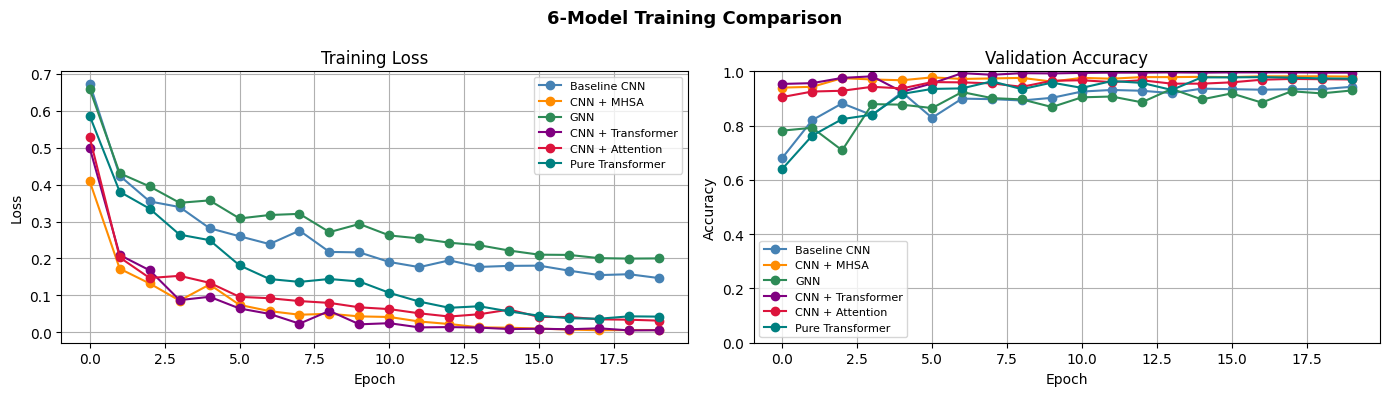

In [14]:
# -- Training curves: all six models ---------------------------------------------
COLORS = ['steelblue', 'darkorange', 'seagreen', 'purple', 'crimson', 'teal']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
for (key, (history, _, label)), color in zip(all_histories.items(), COLORS):
    ax1.plot(history['loss'],    marker='o', color=color, label=label)
    ax2.plot(history['val_acc'], marker='o', color=color, label=label)
ax1.set_title('Training Loss');       ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(fontsize=8); ax1.grid(True)
ax2.set_title('Validation Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1); ax2.legend(fontsize=8); ax2.grid(True)
plt.suptitle('6-Model Training Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_comparison.png', dpi=120)
plt.show()


In [15]:
# ── Classification reports: clean and noisy test sets ────────────────────────
eval_results = {'clean': {}, 'noisy': {}}

for model, key, label in RUNS:
    lbl_c, prd_c, prb_c = evaluate_model(model, key, test_loader)
    lbl_n, prd_n, prb_n = evaluate_model(model, key, noisy_test_loader)
    eval_results['clean'][key] = (lbl_c, prd_c, prb_c, label)
    eval_results['noisy'][key] = (lbl_n, prd_n, prb_n, label)
    print('='*58)
    print(f'  {label}')
    print('='*58)
    print('  CLEAN TEST')
    print(classification_report(lbl_c, prd_c, target_names=CLASSES, digits=3))
    print('  NOISY TEST  (SNR -5 to +20 dB, all samples)')
    print(classification_report(lbl_n, prd_n, target_names=CLASSES, digits=3))


  Baseline CNN
  CLEAN TEST
              precision    recall  f1-score   support

muzzle_blast      0.984     0.946     0.965       848
   shockwave      0.661     0.860     0.748        93
        none      0.949     1.000     0.974        93

    accuracy                          0.943      1034
   macro avg      0.865     0.935     0.895      1034
weighted avg      0.952     0.943     0.946      1034

  NOISY TEST  (SNR -5 to +20 dB, all samples)
              precision    recall  f1-score   support

muzzle_blast      0.849     0.954     0.898       848
   shockwave      0.560     0.452     0.500        93
        none      0.000     0.000     0.000        93

    accuracy                          0.823      1034
   macro avg      0.470     0.469     0.466      1034
weighted avg      0.747     0.823     0.782      1034

  CNN + MHSA
  CLEAN TEST
              precision    recall  f1-score   support

muzzle_blast      0.991     0.987     0.989       848
   shockwave      0.885     0

C:\Users\choub\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\choub\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\choub\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

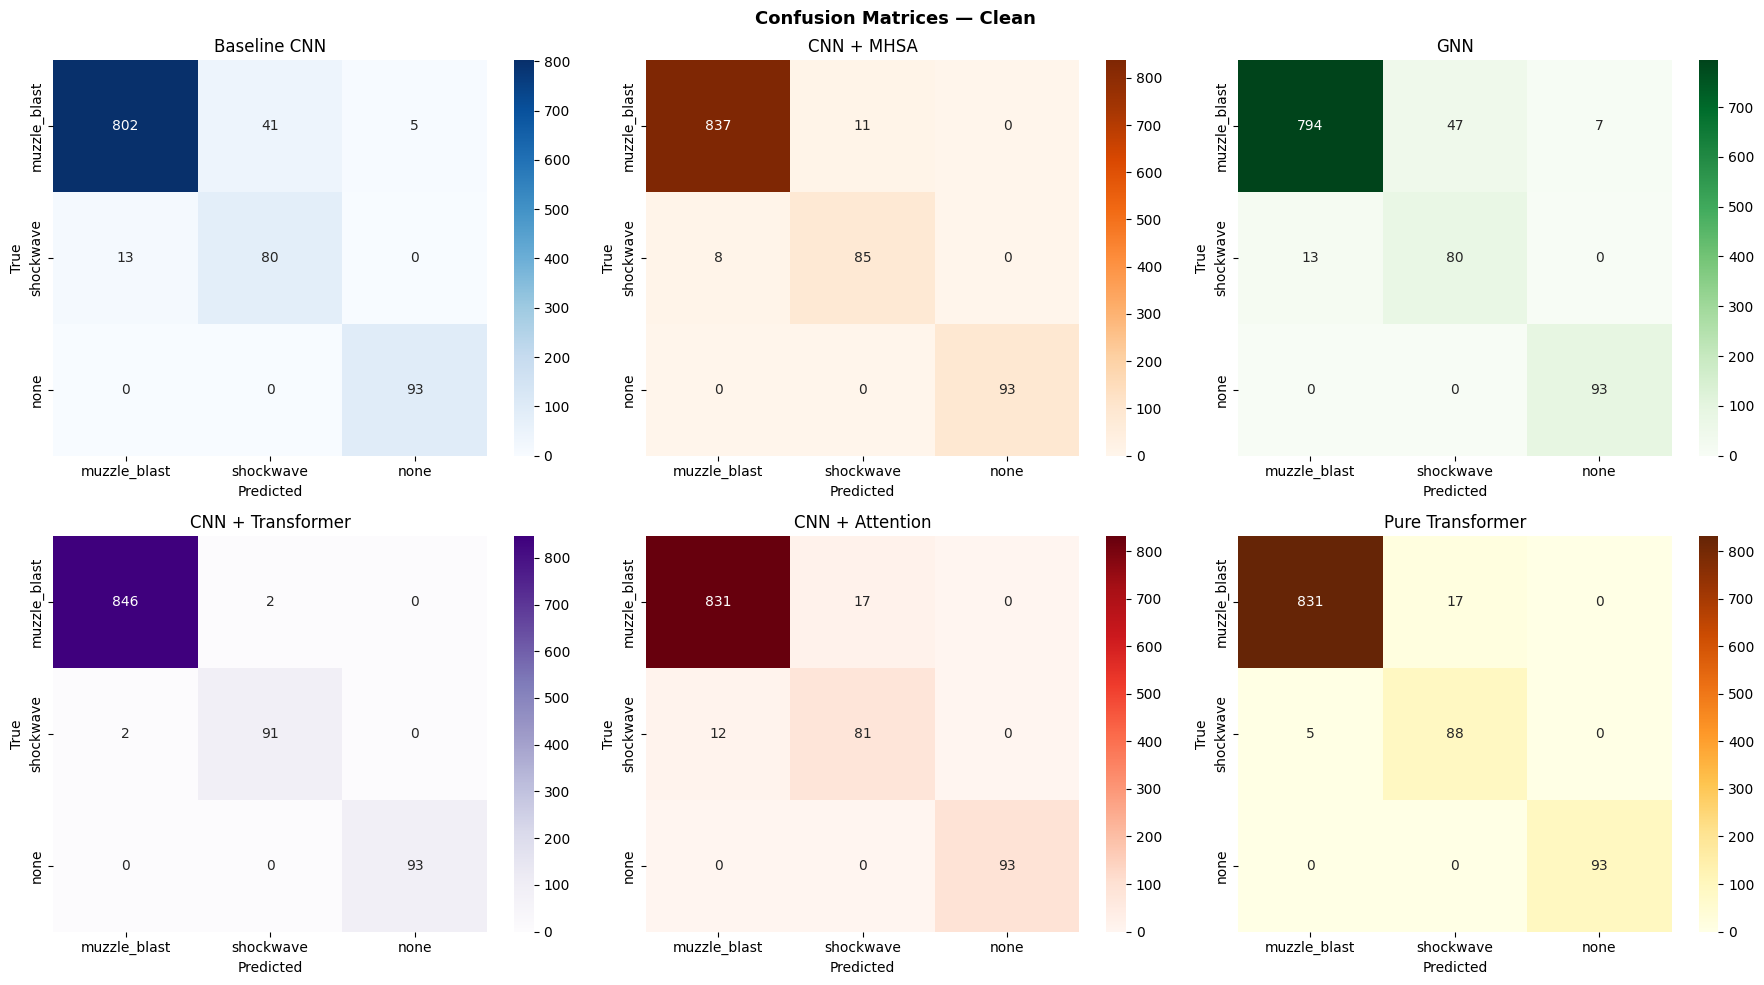

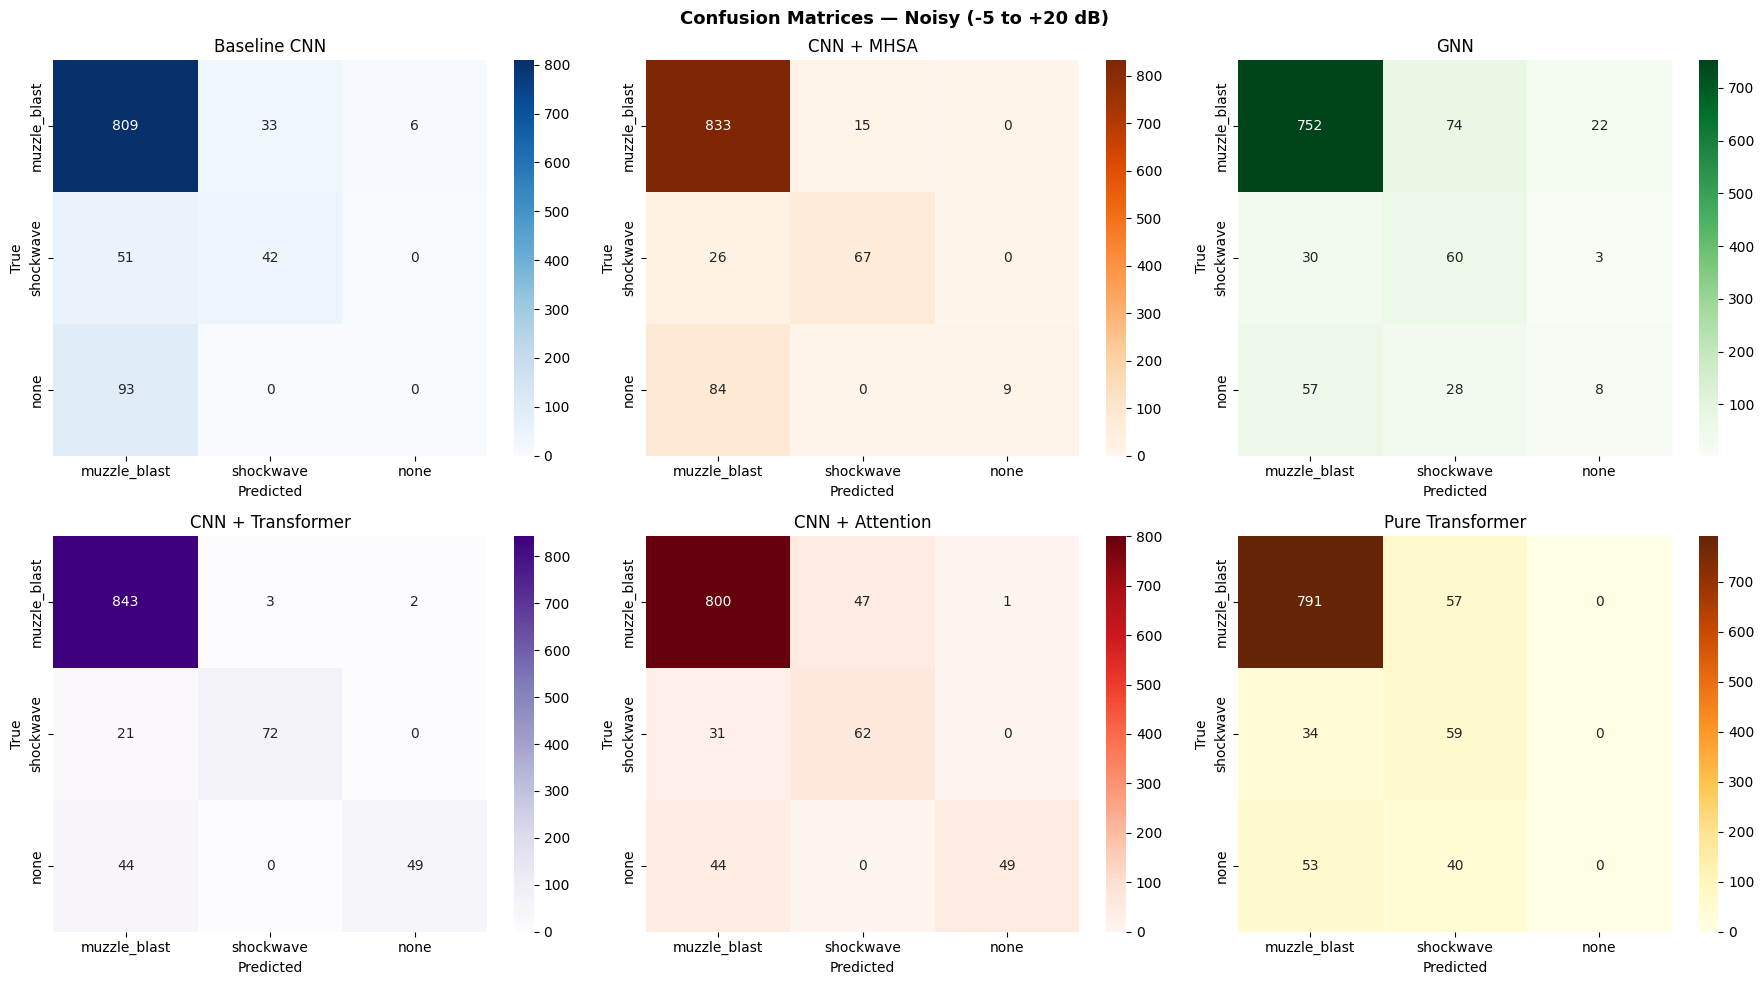

In [16]:
# ── Confusion matrices: clean (top) and noisy (bottom) ───────────────────────
CMAPS = ['Blues', 'Oranges', 'Greens', 'Purples', 'Reds', 'YlOrBr']

for condition, results in [('Clean', eval_results['clean']),
                             ('Noisy (-5 to +20 dB)', eval_results['noisy'])]:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for i, (key, (lbl, prd, _, label)) in enumerate(results.items()):
        cm = confusion_matrix(lbl, prd)
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                    xticklabels=CLASSES, yticklabels=CLASSES, cmap=CMAPS[i])
        axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')
        axes[i].set_title(label)
    plt.suptitle(f'Confusion Matrices — {condition}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = 'confusion_matrices_' + condition.split()[0].lower() + '.png'
    plt.savefig(fname, dpi=120)
    plt.show()


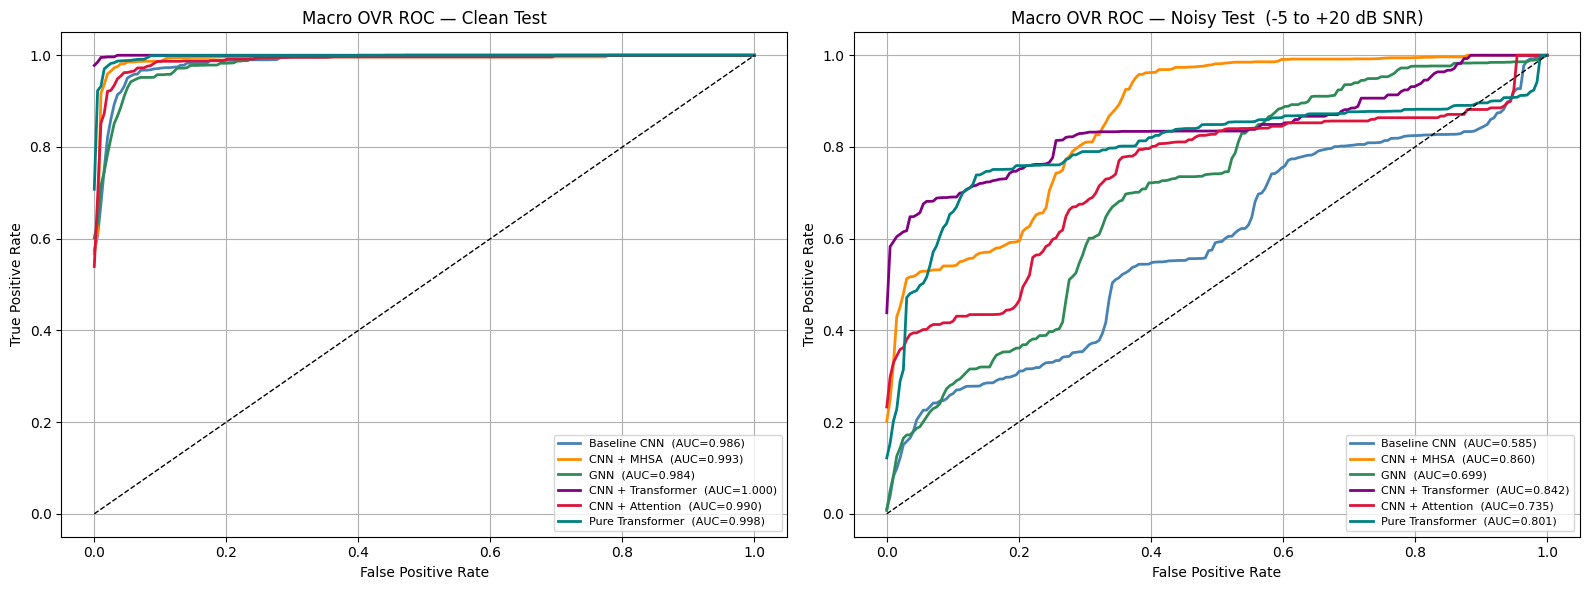


  CLEAN vs NOISY — 3-CLASS (muzzle_blast / shockwave / none)
            Model Clean Acc Noisy Acc Acc Drop Clean AUC Noisy AUC AUC Drop Clean Mac-F1 Noisy Mac-F1 Clean MB-F1 Noisy MB-F1 Clean SW-F1 Noisy SW-F1 Clean None-F1 Noisy None-F1
     Baseline CNN     0.943     0.823   +0.120     0.986     0.585   +0.401        0.895        0.466       0.965       0.898       0.748       0.500         0.974         0.000
       CNN + MHSA     0.982     0.879   +0.103     0.993     0.860   +0.133        0.963        0.624       0.989       0.930       0.899       0.766         1.000         0.176
              GNN     0.935     0.793   +0.142     0.984     0.699   +0.284        0.884        0.496       0.960       0.892       0.727       0.471         0.964         0.127
CNN + Transformer     0.996     0.932   +0.064     1.000     0.842   +0.158        0.992        0.833       0.998       0.960       0.978       0.857         1.000         0.681
  CNN + Attention     0.972     0.881   +0.091  

In [17]:
# ── ROC curves (macro OVR) + clean vs noisy summary ─────────────────────────
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

COLORS   = ['steelblue', 'darkorange', 'seagreen', 'purple', 'crimson', 'teal']
mean_fpr = np.linspace(0, 1, 200)
n_cls    = len(CLASSES)

def macro_ovr_roc(labels, probs):
    """Macro-average one-vs-rest ROC curve and AUC for n_cls classes."""
    lb   = label_binarize(labels, classes=list(range(n_cls)))
    tprs = []
    for c in range(n_cls):
        fpr_c, tpr_c, _ = roc_curve(lb[:, c], probs[:, c])
        tprs.append(np.interp(mean_fpr, fpr_c, tpr_c))
    macro_auc = roc_auc_score(lb, probs, multi_class='ovr', average='macro')
    return mean_fpr, np.mean(tprs, axis=0), macro_auc

fig, (ax_c, ax_n) = plt.subplots(1, 2, figsize=(16, 6))
rows = []

for (key, (lbl_c, prd_c, prb_c, label)), color in zip(eval_results['clean'].items(), COLORS):
    lbl_n, prd_n, prb_n, _ = eval_results['noisy'][key]

    _, tpr_c, auc_c = macro_ovr_roc(lbl_c, prb_c)
    _, tpr_n, auc_n = macro_ovr_roc(lbl_n, prb_n)

    ax_c.plot(mean_fpr, tpr_c, lw=2, color=color, label=f'{label}  (AUC={auc_c:.3f})')
    ax_n.plot(mean_fpr, tpr_n, lw=2, color=color, label=f'{label}  (AUC={auc_n:.3f})')

    acc_c  = accuracy_score(lbl_c, prd_c)
    acc_n  = accuracy_score(lbl_n, prd_n)
    # Per-class F1 (one-vs-rest, so labels=[c] with average='macro' = that class's F1)
    mb_f1c   = f1_score(lbl_c, prd_c, labels=[0], average='macro')  # muzzle_blast
    mb_f1n   = f1_score(lbl_n, prd_n, labels=[0], average='macro')
    sw_f1c   = f1_score(lbl_c, prd_c, labels=[1], average='macro')  # shockwave
    sw_f1n   = f1_score(lbl_n, prd_n, labels=[1], average='macro')
    none_f1c = f1_score(lbl_c, prd_c, labels=[2], average='macro')  # none
    none_f1n = f1_score(lbl_n, prd_n, labels=[2], average='macro')
    # Macro F1 across all 3 classes
    mac_c  = f1_score(lbl_c, prd_c, average='macro')
    mac_n  = f1_score(lbl_n, prd_n, average='macro')
    rows.append({
        'Model':         label,
        'Clean Acc':     f'{acc_c:.3f}',
        'Noisy Acc':     f'{acc_n:.3f}',
        'Acc Drop':      f'{acc_c - acc_n:+.3f}',
        'Clean AUC':     f'{auc_c:.3f}',
        'Noisy AUC':     f'{auc_n:.3f}',
        'AUC Drop':      f'{auc_c - auc_n:+.3f}',
        'Clean Mac-F1':  f'{mac_c:.3f}',
        'Noisy Mac-F1':  f'{mac_n:.3f}',
        'Clean MB-F1':   f'{mb_f1c:.3f}',
        'Noisy MB-F1':   f'{mb_f1n:.3f}',
        'Clean SW-F1':   f'{sw_f1c:.3f}',
        'Noisy SW-F1':   f'{sw_f1n:.3f}',
        'Clean None-F1': f'{none_f1c:.3f}',
        'Noisy None-F1': f'{none_f1n:.3f}',
    })

for ax, title in [(ax_c, 'Clean Test'), (ax_n, 'Noisy Test  (-5 to +20 dB SNR)')]:
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Macro OVR ROC — {title}')
    ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig('roc_curves_clean_vs_noisy.png', dpi=120)
plt.show()

summary = pd.DataFrame(rows)
print('\n' + '=' * 100)
print('  CLEAN vs NOISY — 3-CLASS (muzzle_blast / shockwave / none)')
print('=' * 100)
print(summary.to_string(index=False))
print('=' * 100)

winner_c = summary.loc[summary['Clean AUC'].astype(float).idxmax(), 'Model']
winner_n = summary.loc[summary['Noisy AUC'].astype(float).idxmax(), 'Model']
robust   = summary.loc[summary['AUC Drop'].astype(float).idxmin(),  'Model']
print(f'\n  Best by Clean AUC  : {winner_c}')
print(f'  Best by Noisy AUC  : {winner_n}')
print(f'  Most noise-robust  : {robust}  (smallest AUC drop)')


  CORRUPTED TEST BROKEN DOWN BY SNR BAND  (models trained WITHOUT noise)
  Low (-5 to +3 dB)   Medium (+3 to +12 dB)   High (+12 to +20 dB)
            Model            SNR Band  N Ev Event Acc MB Rec SW Rec ->none MB<->SW Macro-F1* Macro AUC*
     Baseline CNN     Low (-5..+3 dB)   283     0.883  0.942  0.280  0.007   0.110     0.368      0.511
     Baseline CNN Medium (+3..+12 dB)   335     0.919  0.970  0.455  0.003   0.078     0.455      0.569
     Baseline CNN  High (+12..+20 dB)   323     0.907  0.948  0.571  0.009   0.084     0.471      0.519
       CNN + MHSA     Low (-5..+3 dB)   283     0.915  0.965  0.400  0.000   0.085     0.484      0.773
       CNN + MHSA Medium (+3..+12 dB)   335     0.967  0.990  0.758  0.000   0.033     0.620      0.849
       CNN + MHSA  High (+12..+20 dB)   323     0.981  0.990  0.914  0.000   0.019     0.651      0.860
              GNN     Low (-5..+3 dB)   283     0.753  0.775  0.520  0.071   0.177     0.380      0.579
              GNN Medium (+3

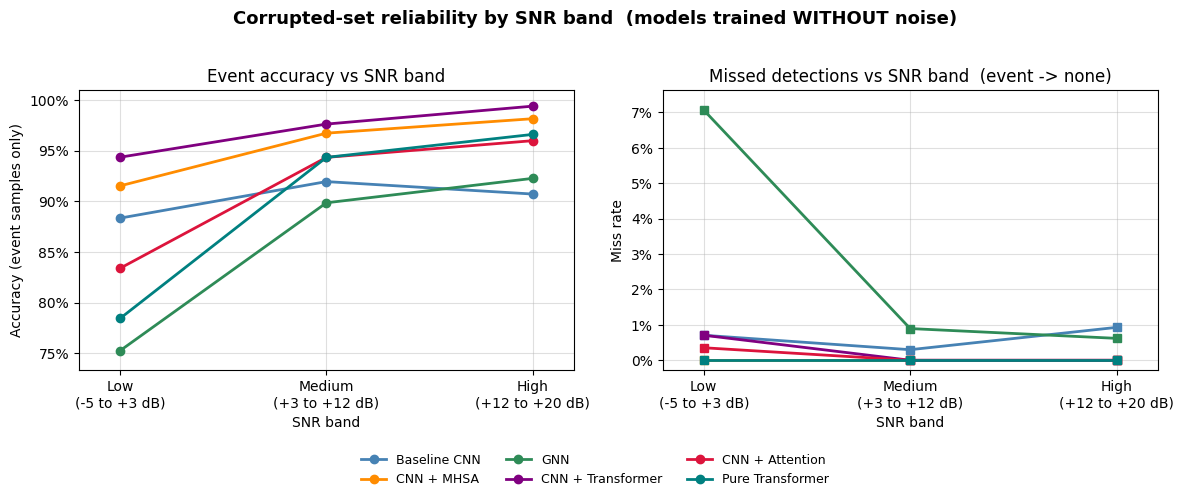


  DEPLOYMENT READ-OUT  (usable band = event accuracy >= 0.90)
  Low (-5 to +3 dB)        best: CNN + Transformer    acc=0.943  miss=0.007
  Medium (+3 to +12 dB)    best: CNN + Transformer    acc=0.976  miss=0.000
  High (+12 to +20 dB)     best: CNN + Transformer    acc=0.994  miss=0.000
--------------------------------------------------------------------------------------------
  Baseline CNN         usable in: Medium, High             (Low=0.883  Med=0.919  High=0.907)
  CNN + MHSA           usable in: Low, Medium, High        (Low=0.915  Med=0.967  High=0.981)
  GNN                  usable in: High                     (Low=0.753  Med=0.899  High=0.923)
  CNN + Transformer    usable in: Low, Medium, High        (Low=0.943  Med=0.976  High=0.994)
  CNN + Attention      usable in: Medium, High             (Low=0.834  Med=0.943  High=0.960)
  Pure Transformer     usable in: Medium, High             (Low=0.784  Med=0.943  High=0.966)


In [19]:
# -- Corrupted results broken down by SNR band --------------------------------
# The aggregate noisy column above averages the whole SNR sweep together and so
# hides where the system actually breaks down.  Here the SAME corrupted
# predictions are re-scored inside the three SNR bands.
#
# How to read the table:
#   * Event Acc / MB Rec / SW Rec / ->none / MB<->SW use ONLY the event samples
#     whose mixing SNR falls inside the band.
#   * Macro-F1* and Macro AUC* additionally include the FULL 'none' set: a
#     'none' sample is pure ambience with no underlying signal, so it has no
#     SNR and cannot be assigned to a band.  Including it keeps those two
#     columns on the same 3-class footing as the aggregate table, at the cost
#     of repeating the same 'none' samples in every band.
#   * '->none' is the operationally important miss rate: a real gunshot event
#     classified as background.
#   * 'MB<->SW' is the event-type confusion rate (muzzle blast called shockwave
#     or vice versa) - the event was still detected, just mislabelled.

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

_none_mask  = np.isnan(noisy_snr)
_band_masks = {
    n: snr_band_mask(noisy_snr, lo, hi, include_hi=(n == SNR_BANDS[-1][0]))
    for n, lo, hi in SNR_BANDS
}

band_rows = []
band_acc  = {}    # model label -> [event accuracy per band]
band_miss = {}    # model label -> [event->none miss rate per band]

for key, (lbl_n, prd_n, prb_n, label) in eval_results['noisy'].items():
    y = np.asarray(lbl_n)
    p = np.asarray(prd_n)
    band_acc[label], band_miss[label] = [], []

    for name, lo, hi in SNR_BANDS:
        m    = _band_masks[name]
        n_ev = int(m.sum())
        if n_ev == 0:
            band_acc[label].append(np.nan)
            band_miss[label].append(np.nan)
            continue

        yb, pb  = y[m], p[m]
        ev_acc  = accuracy_score(yb, pb)
        mb, sw  = yb == 0, yb == 1
        mb_rec  = (pb[mb] == 0).mean() if mb.any() else np.nan
        sw_rec  = (pb[sw] == 1).mean() if sw.any() else np.nan
        to_none = (pb == 2).mean()                     # event judged background
        swapped = ((pb != 2) & (pb != yb)).mean()      # muzzle <-> shockwave

        # Band events + the complete 'none' set, for the 3-class macro metrics
        sub    = m | _none_mask
        mac_f1 = f1_score(y[sub], p[sub], average='macro')
        try:
            auc_b = roc_auc_score(
                label_binarize(y[sub], classes=list(range(len(CLASSES)))),
                prb_n[sub], multi_class='ovr', average='macro')
        except ValueError:
            auc_b = np.nan

        band_acc[label].append(ev_acc)
        band_miss[label].append(to_none)
        band_rows.append({
            'Model':      label,
            'SNR Band':   f'{name} ({lo:+d}..{hi:+d} dB)',
            'N Ev':       n_ev,
            'Event Acc':  f'{ev_acc:.3f}',
            'MB Rec':     f'{mb_rec:.3f}',
            'SW Rec':     f'{sw_rec:.3f}',
            '->none':     f'{to_none:.3f}',
            'MB<->SW':    f'{swapped:.3f}',
            'Macro-F1*':  f'{mac_f1:.3f}',
            'Macro AUC*': f'{auc_b:.3f}',
        })

snr_breakdown = pd.DataFrame(band_rows)
snr_breakdown.to_csv('snr_band_breakdown_clean.csv', index=False)

print('=' * 104)
print('  CORRUPTED TEST BROKEN DOWN BY SNR BAND  (models trained WITHOUT noise)')
print('  ' + '   '.join(SNR_BAND_LABEL[n] for n, _, _ in SNR_BANDS))
print('=' * 104)
print(snr_breakdown.to_string(index=False))
print('=' * 104)
print("  * Macro-F1 / Macro AUC are scored on the band's events plus the full")
print("    'none' set ('none' is pure ambience and carries no SNR).")

# -- Event accuracy pivot: the at-a-glance deployment table --------------------
_order = [f'{n} ({lo:+d}..{hi:+d} dB)' for n, lo, hi in SNR_BANDS]
pivot  = snr_breakdown.copy()
pivot['Event Acc'] = pivot['Event Acc'].astype(float)
pivot = pivot.pivot(index='Model', columns='SNR Band', values='Event Acc')[_order]
pivot['Low->High gain'] = pivot[_order[-1]] - pivot[_order[0]]
print('\n' + '=' * 92)
print('  EVENT ACCURACY BY SNR BAND  (events only; higher SNR = quieter background)')
print('=' * 92)
print(pivot.round(3).to_string())
print('=' * 92)

# -- Plots ---------------------------------------------------------------------
# Accuracy clusters high and the miss rate clusters low, so a fixed 0-1 axis
# would spend most of each panel on empty space and flatten the between-band
# differences that are the whole point of the figure.  Each axis is fitted to
# its own data instead, with a floor on the span so a near-flat model does not
# get blown up into fake drama.
import matplotlib.ticker as mtick

COLORS = ['steelblue', 'darkorange', 'seagreen', 'purple', 'crimson', 'teal']
xs     = np.arange(len(SNR_BANDS))
xlbl   = [SNR_BAND_LABEL[n].replace(' (', '\n(') for n, _, _ in SNR_BANDS]


def fit_yaxis(ax, series, pad=0.08, min_span=0.04):
    """Fit the y-axis to the plotted values and label it as a percentage."""
    vals = np.concatenate([np.asarray(s, dtype=float).ravel() for s in series])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return
    lo, hi = float(vals.min()), float(vals.max())
    span   = max(hi - lo, min_span)
    # A sliver below 0 (and above 1) keeps a perfect 0% / 100% line off the
    # spine where it would otherwise be invisible.  Tick labels stay in range.
    lo = max(-0.5 * pad * span, lo - pad * span)
    hi = min(1.0 + 0.5 * pad * span, hi + pad * span)
    if hi - lo < min_span:                  # every model flat: keep a readable window
        mid    = 0.5 * (lo + hi)
        lo, hi = max(0.0, mid - 0.5 * min_span), min(1.0, mid + 0.5 * min_span)
    ax.set_ylim(lo, hi)
    ax.yaxis.set_major_formatter(
        mtick.PercentFormatter(xmax=1, decimals=0 if hi - lo >= 0.05 else 1))


fig, (ax_a, ax_m) = plt.subplots(1, 2, figsize=(12, 5.0))
for (label, accs), color in zip(band_acc.items(), COLORS):
    ax_a.plot(xs, accs,             marker='o', lw=2, ms=6, color=color, label=label)
    ax_m.plot(xs, band_miss[label], marker='s', lw=2, ms=6, color=color, label=label)

ax_a.set_title('Event accuracy vs SNR band')
ax_a.set_ylabel('Accuracy (event samples only)')
ax_m.set_title('Missed detections vs SNR band  (event -> none)')
ax_m.set_ylabel('Miss rate')
fit_yaxis(ax_a, list(band_acc.values()))
fit_yaxis(ax_m, list(band_miss.values()))
for ax in (ax_a, ax_m):
    ax.set_xticks(xs); ax.set_xticklabels(xlbl)
    ax.set_xlabel('SNR band')
    ax.margins(x=0.10)                      # keep end markers off the spines
    ax.grid(True, alpha=0.4)

# One shared legend below the panels: the fitted axes leave no room inside.
handles, labels = ax_a.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, 0.005))
plt.suptitle('Corrupted-set reliability by SNR band  (models trained WITHOUT noise)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.11, 1, 0.96])
plt.savefig('snr_band_breakdown_clean.png', dpi=120)
plt.show()

# -- Deployment read-out -------------------------------------------------------
TARGET = 0.90   # event accuracy a deployment would need to call a band usable
print('\n' + '=' * 92)
print(f'  DEPLOYMENT READ-OUT  (usable band = event accuracy >= {TARGET:.2f})')
print('=' * 92)
for i, (name, lo, hi) in enumerate(SNR_BANDS):
    best = max(band_acc, key=lambda k: band_acc[k][i])
    print(f'  {SNR_BAND_LABEL[name]:<24} best: {best:<20} '
          f'acc={band_acc[best][i]:.3f}  miss={band_miss[best][i]:.3f}')
print('-' * 92)
for label, accs in band_acc.items():
    ok   = [SNR_BANDS[i][0] for i, a in enumerate(accs) if a >= TARGET]
    span = ', '.join(ok) if ok else 'no band'
    print(f'  {label:<20} usable in: {span:<24} '
          f'(Low={accs[0]:.3f}  Med={accs[1]:.3f}  High={accs[2]:.3f})')
print('=' * 92)
